## Read the data & inital exploration

In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [104]:
df= pd.read_csv('Data/Global_Smartwatch_Marketplace_Insights_2026.csv')

In [105]:
df.columns

Index(['brand', 'condition', 'Case_Size_mm', 'Country', 'price', 'Seller_ID',
       'Is_Worldwide_Shipping', 'title'],
      dtype='object')

In [106]:
df.shape

(3607, 8)

#### Data gồm 3607 hàng và 8 cột

In [107]:
df.describe()

,Case_Size_mm,price,Is_Worldwide_Shipping
count,2729.000000,3607.000000,3607.000000
mean,45.942836,617.819739,0.273357
std,3.165700,1071.008291,0.445745
min,26.000000,120.000000,0.000000
25%,44.000000,458.745000,0.000000
50%,46.000000,550.000000,0.000000
75%,49.000000,699.000000,1.000000
max,52.000000,49900.000000,1.000000


In [108]:
df.head(10)

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title
0,Garmin,Used,NaN,Japan,999.76,Seller_0001,1,Garmin fenix 7 Pro Sapphire Dual Power Watch 4...
1,Garmin,Used,NaN,Japan,928.00,Seller_0002,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...
2,Garmin,Used,50.0,Japan,934.92,Seller_0001,1,Garmin Fenix 7X Pro Solar Sapphire 50mm GPS Mu...
3,Garmin,New,NaN,Canada,1200.00,Seller_0003,0,garmin tactix 7 amoled edition BNIB
4,Garmin,Used,43.0,Japan,962.08,Seller_0001,1,Garmin Descent MK2S GPS Watch 43mm Light Sand ...
5,Garmin,Used,NaN,Japan,902.28,Seller_0001,1,Garmin Descent Mk1 Dive Computer Smartwatch GP...
6,Garmin,Used,NaN,Japan,913.36,Seller_0001,1,Garmin Venu X1 Black Smartwatch GPS Multisport...
7,Garmin,Used,47.0,Japan,911.44,Seller_0001,1,Garmin Venu X1 AMOLED Sapphire Titanium 47mm G...
8,Garmin,Used,NaN,Japan,908.06,Seller_0001,1,Garmin Epix GPS Porsche Design Smartwatch
9,Garmin,Used,NaN,Japan,884.90,Seller_0001,1,Garmin Tacx FLUX S Smart Direct Drive Trainer ...


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  3607 non-null   object 
 1   condition              3607 non-null   object 
 2   Case_Size_mm           2729 non-null   float64
 3   Country                3607 non-null   object 
 4   price                  3607 non-null   float64
 5   Seller_ID              3607 non-null   object 
 6   Is_Worldwide_Shipping  3607 non-null   int64  
 7   title                  3607 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 225.6+ KB


#### Missing value: Case_Size_mm 
#### khi tổng số hàng là 3607 trong khi Case_Size_mm chỉ có 2729
#### Cần chuyển sang dạng category: Brand, Condition, Country


In [110]:
print(df.nunique())

brand                       5
condition                  14
Case_Size_mm               15
Country                    27
price                    1117
Seller_ID                1754
Is_Worldwide_Shipping       2
title                    3179
dtype: int64


#### Quy trình chuyển sang Category

In [111]:
convert_category= ['brand', 'condition', 'Country']
for col in convert_category:
    df[col]= df[col].astype('category')

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   brand                  3607 non-null   category
 1   condition              3607 non-null   category
 2   Case_Size_mm           2729 non-null   float64 
 3   Country                3607 non-null   category
 4   price                  3607 non-null   float64 
 5   Seller_ID              3607 non-null   object  
 6   Is_Worldwide_Shipping  3607 non-null   int64   
 7   title                  3607 non-null   object  
dtypes: category(3), float64(2), int64(1), object(2)
memory usage: 153.7+ KB


#### Fill missing values bằng cách dùng regex để trích case_size từ Title sau đó sẽ điền trung vị còn thiếu

In [113]:
import re
def get_size_from_title(title):
    title = str(title).lower()
    match = re.search(r'(\d{2})\s*mm', title)
    if match:
        return int(match.group(1))
    return None
df['case_size_regex'] = df['title'].apply(get_size_from_title)

# 3. Kết hợp: Nếu có regex thì lấy, không thì mới lấy trung vị
# Giả sử df['case_size'] là cột gốc đang có nhiều NaN
df['Case_Size_mm'] = df['case_size_regex'].fillna(df.groupby('brand', observed=False)['Case_Size_mm'].transform('median'))
print(f"Số giá trị thiếu còn lại: {df['Case_Size_mm'].isnull().sum()}")

Số giá trị thiếu còn lại: 0


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3607 entries, 0 to 3606
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   brand                  3607 non-null   category
 1   condition              3607 non-null   category
 2   Case_Size_mm           3607 non-null   float64 
 3   Country                3607 non-null   category
 4   price                  3607 non-null   float64 
 5   Seller_ID              3607 non-null   object  
 6   Is_Worldwide_Shipping  3607 non-null   int64   
 7   title                  3607 non-null   object  
 8   case_size_regex        2729 non-null   float64 
dtypes: category(3), float64(3), int64(1), object(2)
memory usage: 181.9+ KB


## Part 1: EDA

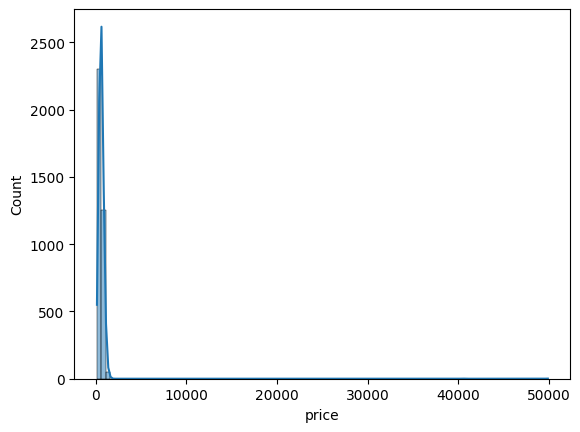

In [115]:
sns.histplot(data= df, x='price', bins=100, kde=True);

#### Có giá trị ngoại lệ ở đây khi chủ yếu giá đồng hồ chỉ tập trung khoảng <5000 nhưng có những đồng hồ trị giá 50000

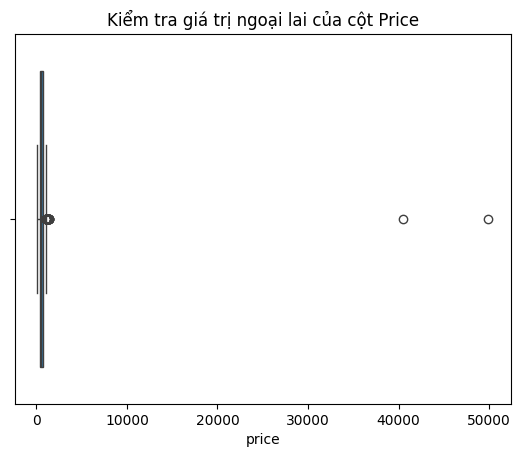

In [116]:
sns.boxplot(data=df, x='price')
plt.title('Kiểm tra giá trị ngoại lai của cột Price')
plt.show()

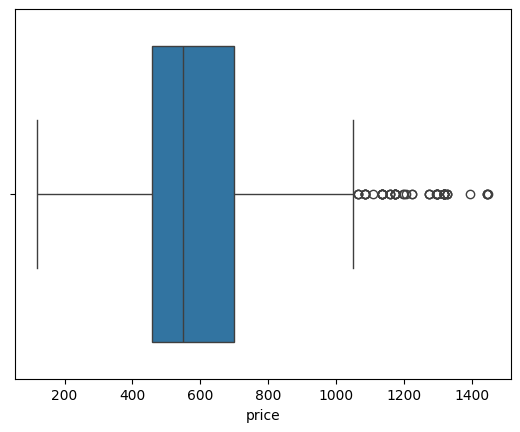

In [117]:
sns.boxplot(data=df[df['price'] < 2000], x='price');

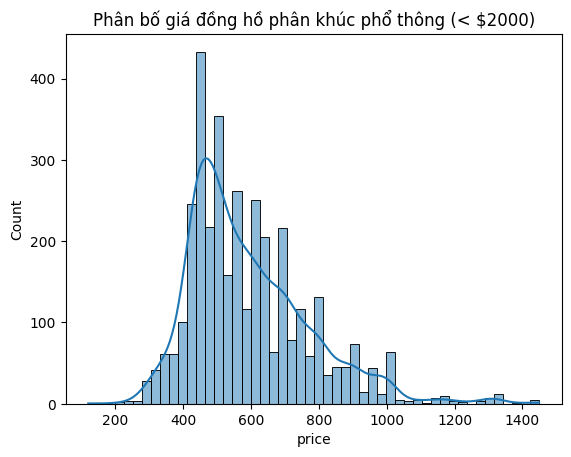

In [118]:
df_filtered = df[df['price'] < 2000]
sns.histplot(data=df_filtered, x='price', bins=50, kde=True)
plt.title('Phân bố giá đồng hồ phân khúc phổ thông (< $2000)')
plt.show()

#### Ở đây cho thấy giá đồng hồ chủ yếu phân bố khoảng 420$-700$

In [119]:
df[df['price'] > 10000]

,brand,condition,Case_Size_mm,Country,price,Seller_ID,Is_Worldwide_Shipping,title,case_size_regex
1662,Apple,Usado,49.0,Estados Unidos,40500.0,Seller_0751,0,"Apple Watch Ultra 2 49mm Titânio, Azul/Preto, ...",49.0
2524,Samsung,Novo,47.0,Estados Unidos,49900.0,Seller_1215,0,Smartwatch (2025) SAMSUNG Galaxy Watch Ultra 4...,47.0


#### Chỉ có 2 sản phẩm có giá tiền vượt trội so với các sản phẩm khác
* Có thể là do lỗi nhập dữ liệu vì dù đồng hồ có mạ vàng hay gì cũng không thể lên con số 40000 được
* Giải pháp ở đây là xoá luôn 2 sản phẩm đó khỏi df để tránh sai sót khi máy tính dự đoán

In [120]:
df=df[df['price']<10000]

In [121]:
df_filtered.value_counts()

brand   condition                Case_Size_mm  Country        price   Seller_ID    Is_Worldwide_Shipping  title                                                                             case_size_regex
Apple   Excellent - Refurbished  49.0          United States  839.95  Seller_0033  0                      Apple Watch Ultra 2 [GPS + Cellular 49mm] Smartwatch with Rugged Titanium Case &  49.0               6
Garmin  New                      41.0          United States  560.99  Seller_0033  0                      Garmin Venu 4, 41mm, Advanced Health and Fitness GPS Smartwatch, Bright and       41.0               5
Apple   Open box                 49.0          United States  450.00  Seller_1270  0                      Apple Watch Ultra 2 49mm Titanium, GPS + Cellular (Open Box)                      49.0               4
Garmin  New                      45.0          United States  560.99  Seller_0033  0                      Garmin Venu 4, 45mm, Advanced Health and Fitness GPS Smartwatch

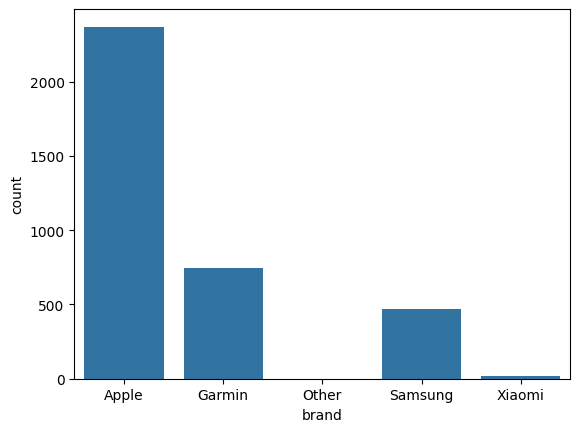

In [122]:
sns.countplot(data=df, x='brand');

In [123]:
df['brand'].unique()

['Garmin', 'Apple', 'Samsung', 'Xiaomi', 'Other']
Categories (5, object): ['Apple', 'Garmin', 'Other', 'Samsung', 'Xiaomi']

In [124]:
brand_counts = df['brand'].value_counts(normalize=True) * 100
print(brand_counts)

brand
Apple      65.714286
Garmin     20.693481
Samsung    13.009709
Xiaomi      0.554785
Other       0.027739
Name: proportion, dtype: float64


#### Từ đây cho thấy Apple chiếm tỉ lệ rất cao khi đến tận 65.7% trong kho Xiaomi hay Other chỉ <1%

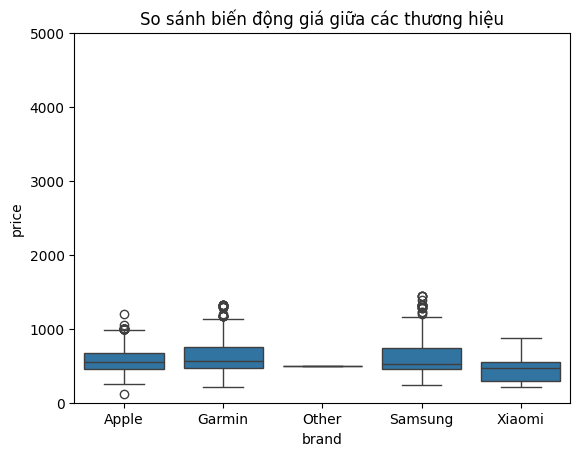

In [125]:
#plt.figure(figsize=(10, 6))
sns.boxplot(x='brand', y='price', data=df);
plt.title('So sánh biến động giá giữa các thương hiệu')
plt.ylim(0, 5000)
plt.show()

#### Gộp Xiaomi vào Other do cả 2 tỉ lệ % quá thấp

In [126]:
df['brand'] = df['brand'].astype(str)
df['brand'] = df['brand'].replace(['Xiaomi', 'Other brand', 'Other'], 'Small brand')
df['brand'] = df['brand'].astype('category')
print(df['brand'].value_counts())

brand
Apple          2369
Garmin          746
Samsung         469
Small brand      21
Name: count, dtype: int64


In [127]:
print(df['condition'].value_counts())

condition
New                         1553
Used                        1250
Open box                     581
Excellent - Refurbished      118
Very Good - Refurbished       40
For parts or not working      21
Good - Refurbished            20
New other                      5
Nuevo                          5
Certified - Refurbished        4
Usado                          4
Caja abierta                   3
--                             1
Novo                           0
Name: count, dtype: int64


* Ở condition có nhiều loại ngôn ngữ khác nhau, chưa kể phần Refurbished lại bị chia nhỏ quá mức
* Giải pháp là gom lại theo cùng một ngôn ngữ

In [128]:
df['condition']=df['condition'].astype(str)
condition_map={
    'New': 'New', 'Nuevo': 'New', 'Novo': 'New', 'New other': 'New',
    'Used': 'Used', 'Usado': 'Used',
    'Open box': 'Open Box', 'Caja abierta': 'Open Box',
    'Excellent - Refurbished': 'Refurbished',
    'Very Good - Refurbished': 'Refurbished',
    'Good - Refurbished': 'Refurbished',
    'Certified - Refurbished': 'Refurbished',
    'For parts or not working': 'Broken/Other',
    '--': 'Broken/Other'
    }
df['condition']=df['condition'].replace(condition_map)
df['condition']=df['condition'].astype('category')  
df['condition'].value_counts()

condition
New             1563
Used            1254
Open Box         584
Refurbished      182
Broken/Other      22
Name: count, dtype: int64

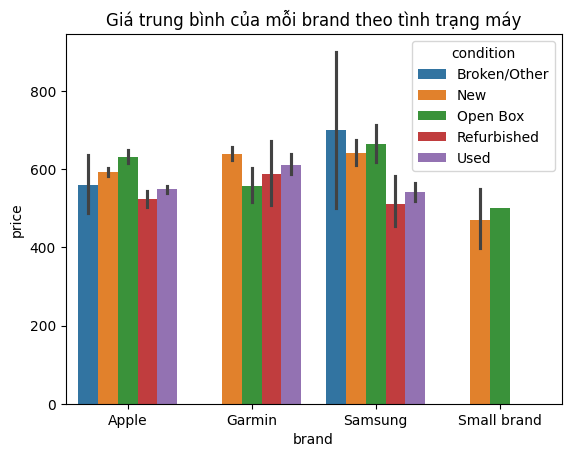

In [129]:
sns.barplot(data=df, x='brand', y='price', hue='condition')
plt.title('Giá trung bình của mỗi brand theo tình trạng máy')
plt.show()

#### Từ biểu đồ cho thấy Apple giữ giá khá tốt khi mức giá chênh lệch giữa New hay Used là tương đối thấp

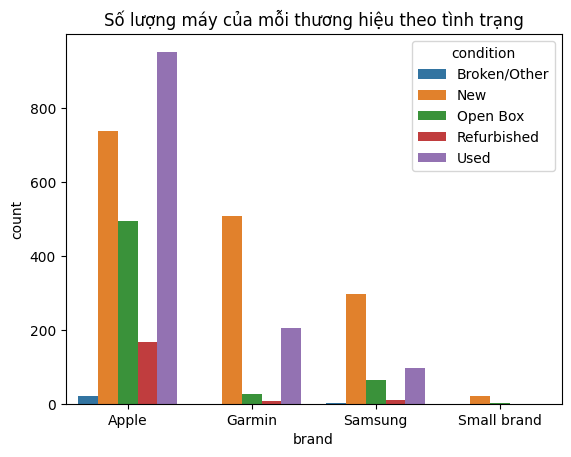

In [130]:
sns.countplot(data=df, x='brand', hue='condition');
plt.title('Số lượng máy của mỗi thương hiệu theo tình trạng');

Điều này cho thấy thị trường Smartwatch cũ của Apple cực kỳ sôi động. Người dùng có xu hướng mua đi bán lại Apple Watch rất nhiều so với các hãng khác

In [131]:
df.groupby(['brand', 'condition'], observed=True)['price'].describe()

count        mean         std     min       25%  \
brand       condition                                                       
Apple       Broken/Other   20.0  558.161000  184.296384  314.99  429.0000   
            New           737.0  592.473202  148.591682  274.95  468.0000   
            Open Box      494.0  632.071437  168.162108  299.99  499.2475   
            Refurbished   166.0  523.442169  135.905699  120.00  429.0000   
            Used          952.0  547.943141  139.557030  249.99  450.0000   
Garmin      New           508.0  638.868583  206.930061  215.10  479.6800   
            Open Box       26.0  556.780000  117.995818  425.00  495.6225   
            Refurbished     7.0  588.268571  125.550269  419.00  494.9950   
            Used          205.0  611.623024  182.519542  280.00  445.0000   
Samsung     Broken/Other    2.0  700.000000  282.842712  500.00  600.0000   
            New           298.0  639.931074  274.700104  244.99  442.5250   
            Open Box       63.0  665.266825  202.194857  309.99  489.9950   
            Refurbished     9.0  511.101111  105.409257  399.99  450.0000   
            Used           97.0  540.931443  118.788378  350.00  450.0000   
Small brand New            20.0  468.981500  178.540613  213.53  290.9350   
            Open Box        1.0  499.990000         NaN  499.99  499.9900   

                              50%       75%      max  
brand       condition                                 
Apple       Broken/Other  509.970  619.9900   999.99  
            New           589.980  700.0000  1000.00  
            Open Box      609.475  722.2500  1199.00  
            Refurbished   489.990  627.9875   896.99  
            Used          502.145  600.0000  1050.00  
Garmin      New           567.450  749.9900  1319.00  
            Open Box      500.000  599.9975   900.00  
            Refurbished   579.990  704.4750   719.95  
            Used          577.960  780.3800   999.76  
Samsung     Broken/Other  700.000  800.0000   900.00  
            New           522.500  764.3175  1449.00  
            Open Box      675.000  799.0000  1000.00  
            Refurbished   450.000  649.9900   649.99  
            Used          517.500  597.9100   968.39  
Small brand New           463.990  545.0000   875.00  
            Open Box      499.990  499.9900   499.99

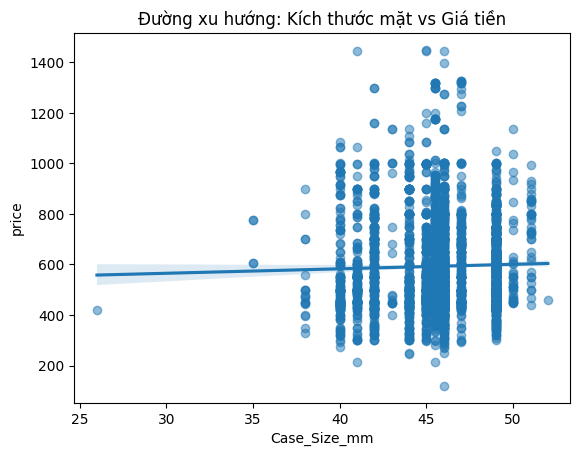

In [132]:
sns.regplot(data=df, x='Case_Size_mm', y='price', scatter_kws={'alpha':0.5})
plt.title('Đường xu hướng: Kích thước mặt vs Giá tiền')
plt.show()

#### Ở đây cho thấy sơ bộ về sự tương quan giữa kích thước và giá tiền

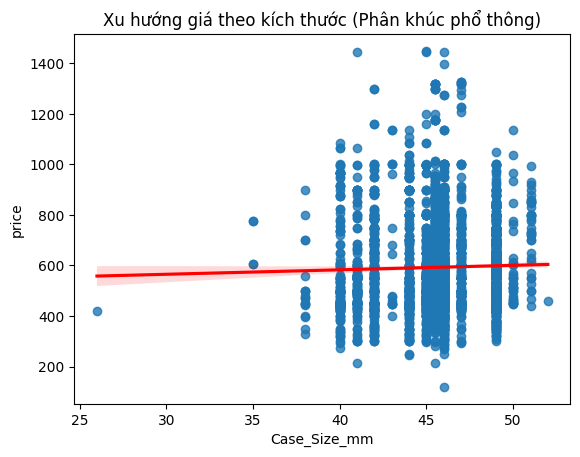

In [133]:
df_zoom = df[df['price'] < 5000]
sns.regplot(data=df_zoom, x='Case_Size_mm', y='price', line_kws={"color": "red"})
plt.title('Xu hướng giá theo kích thước (Phân khúc phổ thông)');

#### Sau khi xem xét ở phân khúc phổ thông:
 * Ta chứng minh được rằng sự tương quan giữa kích thước và giá tiền là rất thấp vì vậy giá tiền không phụ thuộc vào kích thước
 * Sự tương quan giữa kích thước và giá tiền ở toàn bộ sản phẩm so với phổ thông không có sự khác biệt nhiều => Sản phẩm tập trung hầu hết ở mức giá phổ thông

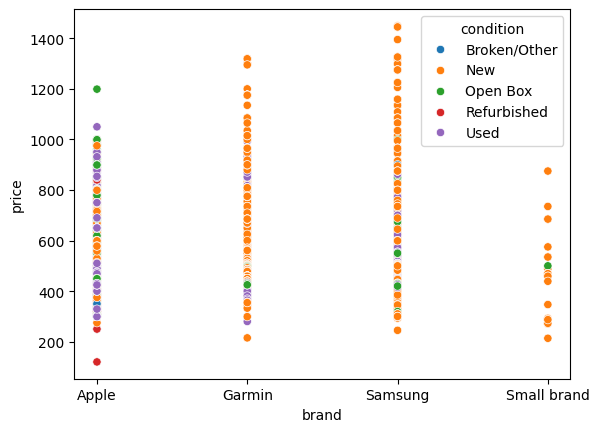

In [134]:
sns.scatterplot(data=df, x='brand', y='price', hue='condition');

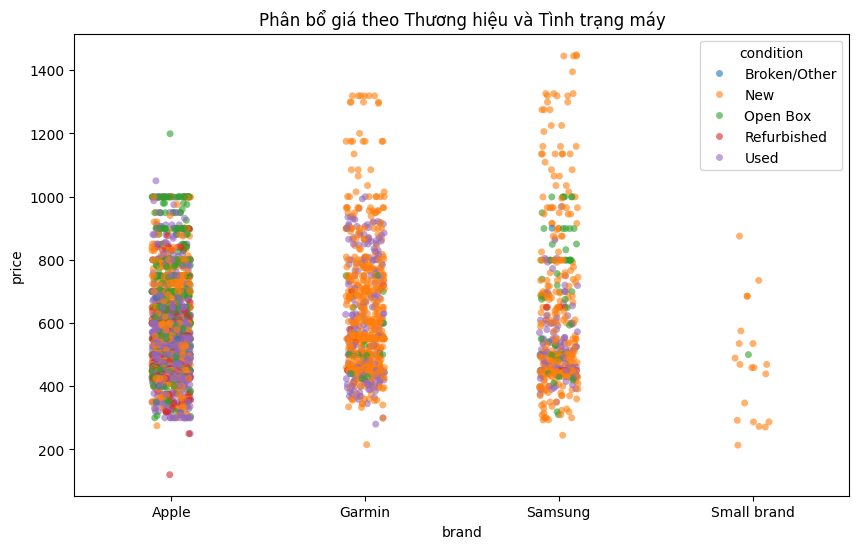

In [135]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='brand', y='price', hue='condition', jitter=True, alpha=0.6)
plt.title('Phân bổ giá theo Thương hiệu và Tình trạng máy')
plt.show()

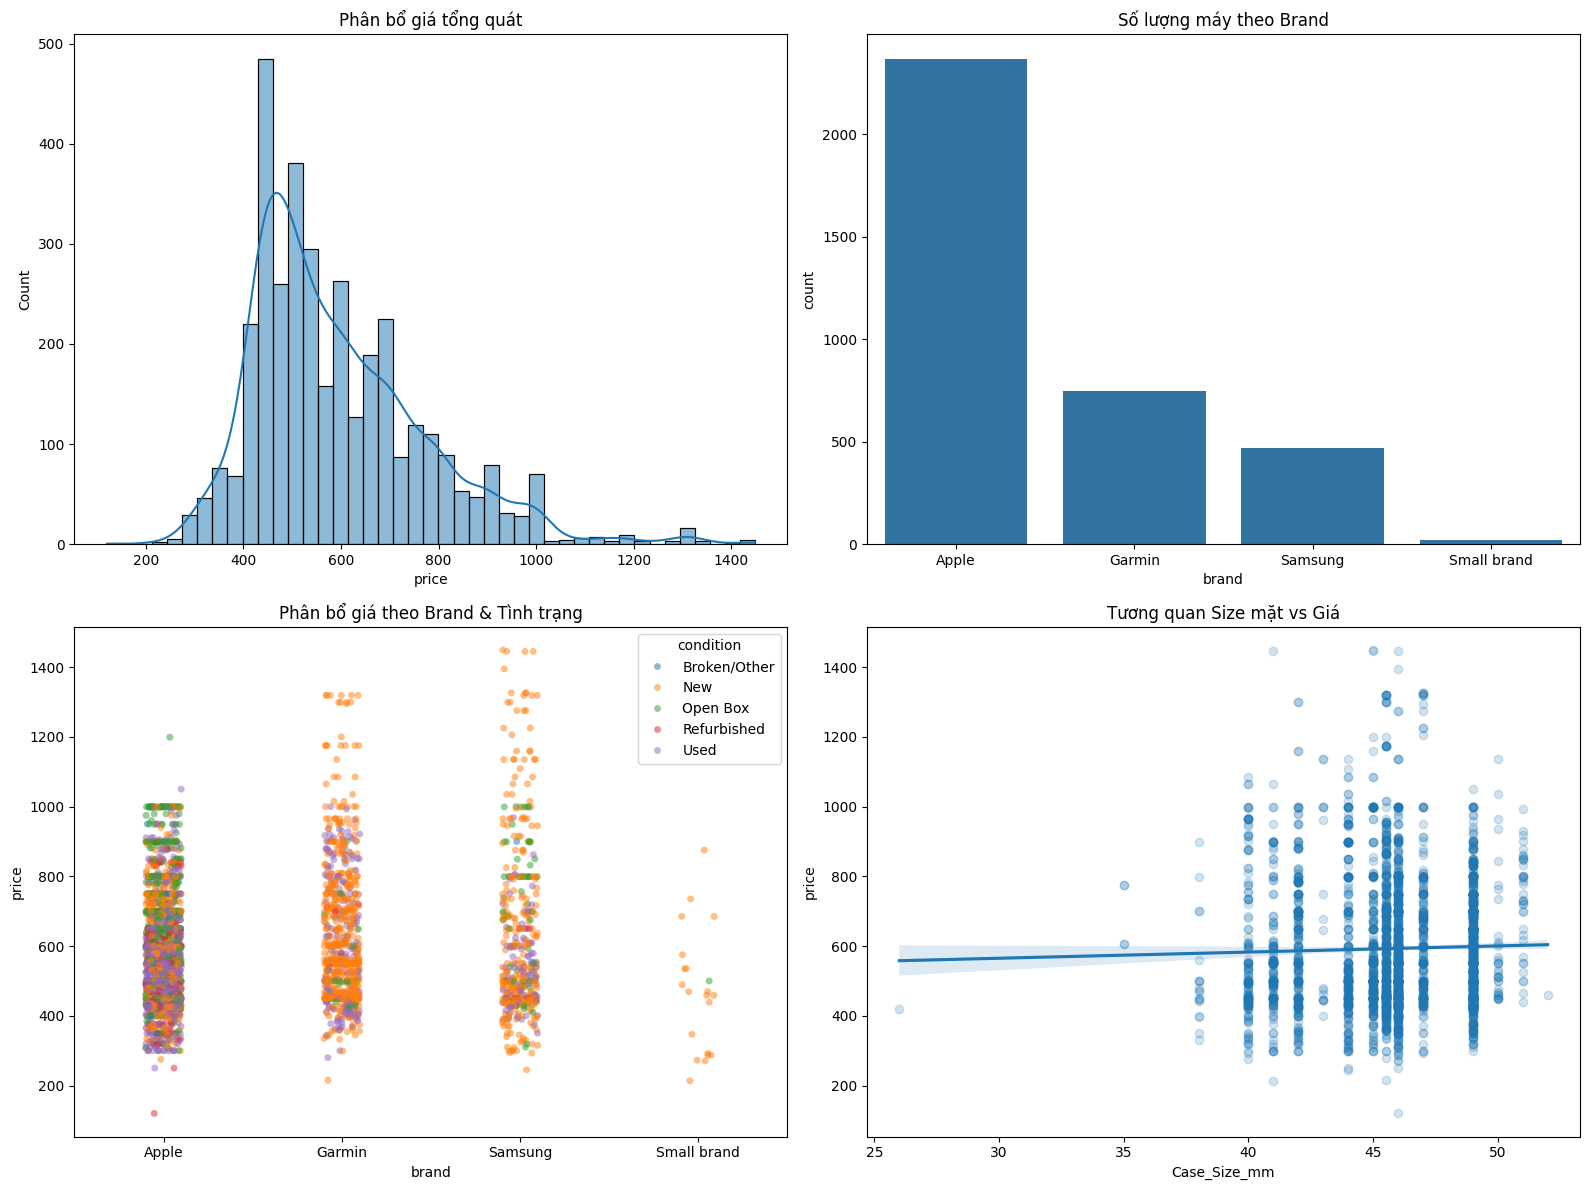

In [136]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

sns.histplot(data=df, x='price', kde=True, ax=ax1)
ax1.set_title('Phân bổ giá tổng quát')

sns.countplot(data=df, x='brand', ax=ax2)
ax2.set_title('Số lượng máy theo Brand')

sns.stripplot(data=df, x='brand', y='price', hue='condition', jitter=True, alpha=0.5, ax=ax3)
ax3.set_title('Phân bổ giá theo Brand & Tình trạng')

sns.regplot(data=df, x='Case_Size_mm', y='price', scatter_kws={'alpha':0.2}, ax=ax4)
ax4.set_title('Tương quan Size mặt vs Giá')

plt.tight_layout()
plt.show()

#### Dùng subplot theo hướng đối tượng để gom các biểu đồ trên cùng một khung hình

In [137]:
country_counts = df['Country'].value_counts().sort_values(ascending=True)
print(country_counts)

Country
Unknown              1
Hungary              1
Belgium              1
Latvia               1
Lithuania            1
Italia               1
Corea del Sur        1
Reino Unido          2
Greece               2
Ireland              2
Netherlands          3
Spain                3
China                5
Estados Unidos       8
France               8
Israel              14
Poland              14
Australia           23
Hong Kong           24
Malaysia            25
Germany             37
Canada              87
Italy              131
Japan              185
South Korea        212
United Kingdom     469
United States     2344
Name: count, dtype: int64


#### Ta thấy ở đây Country được viết thành nhiều ngôn ngữ khác nhau, nếu không sắp xếp lại chung một nhóm thì đó sẽ gây ảnh hưởng đến việc train model sau này

In [138]:
df_country={
    'Estados Unidos': 'United States',
    'Reino Unido': 'United Kingdom',
    'Italia': 'Italy',
    'Corea del Sur': 'South Korea'
}
df['Country']=df['Country'].astype(str)
df['Country']=df['Country'].replace(df_country)
df['Country']=df['Country'].astype('category')
print(df['Country'].value_counts())

Country
United States     2352
United Kingdom     471
South Korea        213
Japan              185
Italy              132
Canada              87
Germany             37
Malaysia            25
Hong Kong           24
Australia           23
Israel              14
Poland              14
France               8
China                5
Netherlands          3
Spain                3
Ireland              2
Greece               2
Belgium              1
Latvia               1
Lithuania            1
Hungary              1
Unknown              1
Name: count, dtype: int64


#### Ta thấy United States có số lượng cao nhất vượt trội hơn hẳn United Kingdom, Liệu có khả nào nào là Apple sẽ có ở United States nhiều nhất tại vì có nguồn gốc từ United States ?

In [139]:
top_countries = df['Country'].value_counts().nlargest(5).index
df['Country'] = df['Country'].astype(str)
df.loc[~df['Country'].isin(top_countries), 'Country'] = 'Other countries'
df['Country'] = df['Country'].astype('category')

#### Do có quá nhiều Country nên khi vẽ biểu đồ sẽ khó mô tả được số liệu nên ta sẽ lấy 5 nước lớn nhất và các nước còn lại sẽ vào nhóm Others

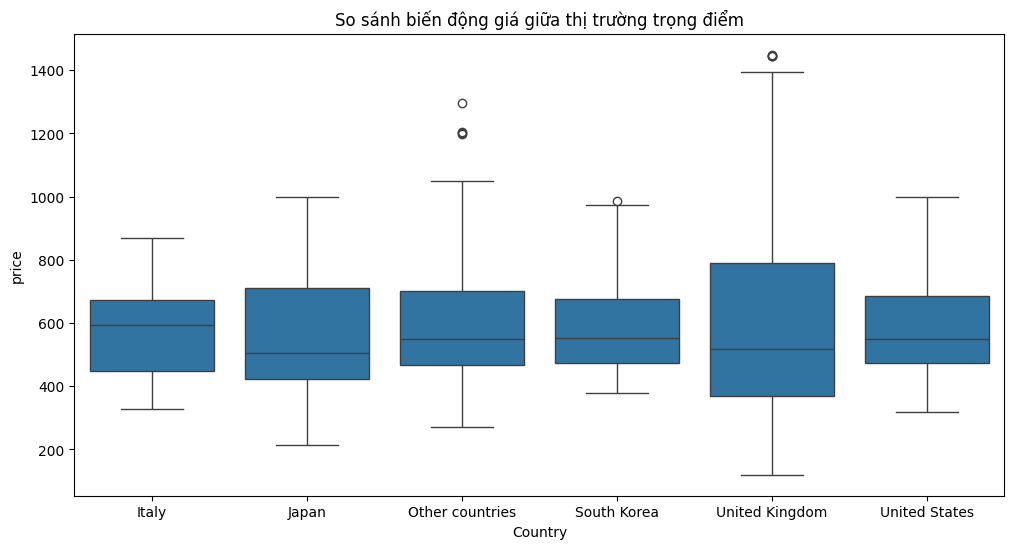

In [140]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Country', y='price');
plt.title('So sánh biến động giá giữa thị trường trọng điểm')
plt.show()

##### Nhận xét về phân phối giá theo Quốc gia:
 * Tính biến động: United Kingdom là thị trường có độ phân hóa giá mạnh nhất, phản ánh sự đa dạng trong danh mục sản phẩm từ bình dân đến cao cấp.

 * Sự ổn định: Italy thể hiện sự nhất quán trong định giá với biên độ dao động thấp nhất trong các thị trường trọng điểm.

* Phân khúc cao cấp: Sự xuất hiện của các outliers ở mức giá >1000 tại UK và nhóm Other countries cho thấy sự tồn tại của phân khúc Smartwatch hạng sang tại các khu vực này.

* Chiến lược mô hình hóa: Do tính chất phân phối giá khác nhau rõ rệt, biến Country chắc chắn là một biến quan trọng cần được đưa vào mô hình dự báo giá.

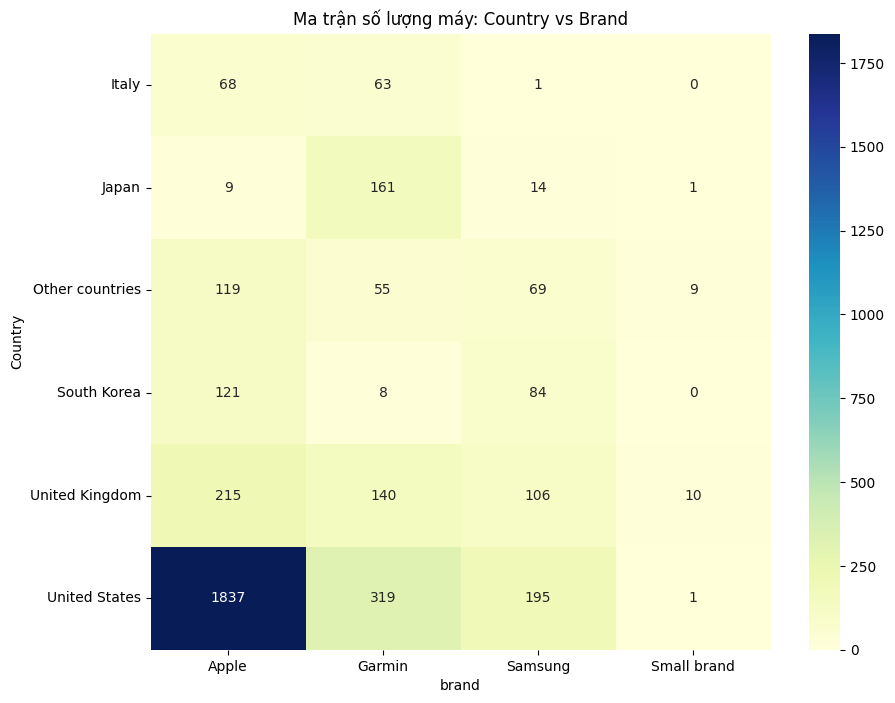

In [141]:
plt.figure(figsize=(10, 8))
sns.heatmap(pd.crosstab(df['Country'], df['brand']), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Ma trận số lượng máy: Country vs Brand')
plt.show()

#### Heatmap đã kiểm chứng được sự nghi ngờ này là hoàn toàn chính xác

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3605 entries, 0 to 3606
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   brand                  3605 non-null   category
 1   condition              3605 non-null   category
 2   Case_Size_mm           3605 non-null   float64 
 3   Country                3605 non-null   category
 4   price                  3605 non-null   float64 
 5   Seller_ID              3605 non-null   object  
 6   Is_Worldwide_Shipping  3605 non-null   int64   
 7   title                  3605 non-null   object  
 8   case_size_regex        2727 non-null   float64 
dtypes: category(3), float64(3), int64(1), object(2)
memory usage: 208.3+ KB


#### Do Is_Worldwide_Shipping chỉ có 0 hoặc 1 nên không cần nhất thiết phải float, ta sẽ chuyển qua category

In [143]:
df['Is_Worldwide_Shipping'].astype('category')
print('Đã chuyển thành công')

Đã chuyển thành công


In [144]:
print(df['Is_Worldwide_Shipping'].value_counts(normalize=True) * 100)

Is_Worldwide_Shipping
0    72.649098
1    27.350902
Name: proportion, dtype: float64


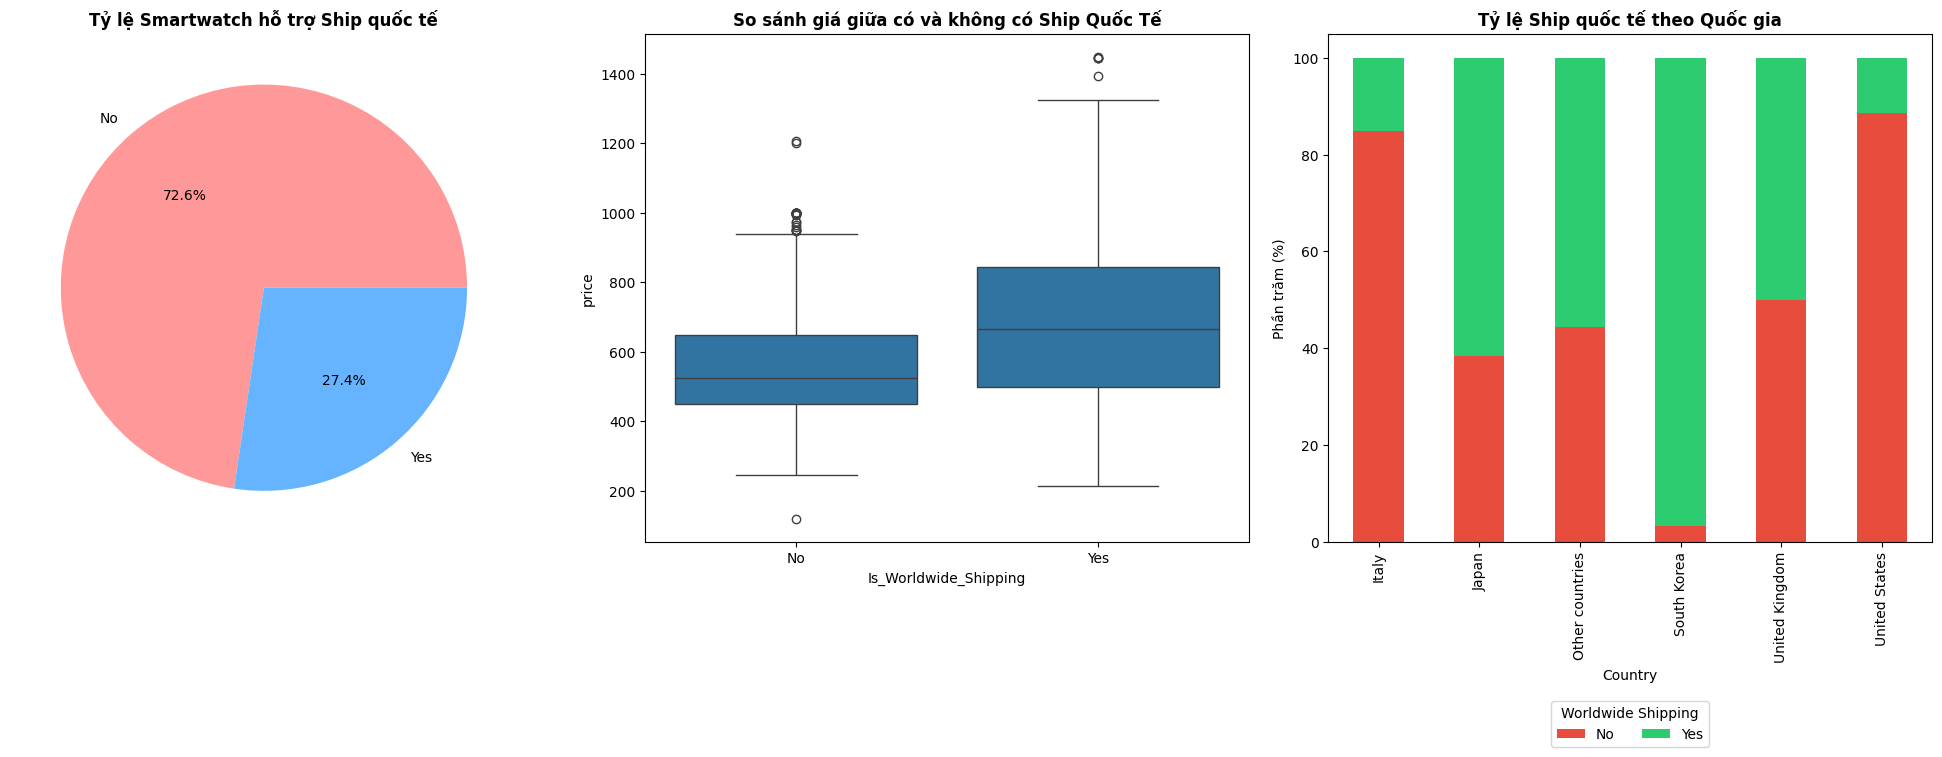

In [145]:
fig, (ax1, ax2, ax3)= plt.subplots(nrows=1, ncols=3, figsize=(20,8))

df['Is_Worldwide_Shipping'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['No', 'Yes'], colors=['#ff9999','#66b3ff'], ax=ax1);
ax1.set_title('Tỷ lệ Smartwatch hỗ trợ Ship quốc tế', fontweight='bold')
ax1.set_ylabel('')

sns.boxplot(data=df, x='Is_Worldwide_Shipping', y='price', ax=ax2);
ax2.set_title('So sánh giá giữa có và không có Ship Quốc Tế', fontweight='bold')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['No', 'Yes']);

ship_by_country = pd.crosstab(df['Country'], df['Is_Worldwide_Shipping'], normalize='index') * 100
ship_by_country.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], legend=False, ax=ax3)
ax3.set_title('Tỷ lệ Ship quốc tế theo Quốc gia', fontweight='bold')
plt.ylabel('Phần trăm (%)')
ax3.legend(title='Worldwide Shipping', labels=['No', 'Yes'], 
           loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2)

plt.tight_layout()
plt.show()
                                

#### Dựa trên bộ 3 biểu đồ trên, chúng ta rút ra được những nhận xét quan trọng sau:

* Tổng quan thị trường: Đa số các sản phẩm trên sàn thương mại này (72.6%) không hỗ trợ vận chuyển quốc tế. Điều này cho thấy các giao dịch chủ yếu diễn ra trong phạm vi nội địa của từng quốc gia.

* Mối tương quan với giá (Price): * Có một sự chênh lệch rõ rệt về giá: Nhóm có hỗ trợ Ship quốc tế (Yes) có giá trung vị (median) cao hơn hẳn so với nhóm không hỗ trợ.

* Các sản phẩm "siêu cao cấp" (Outliers trên 1200) hầu hết đều nằm ở nhóm hỗ trợ vận chuyển quốc tế. Điều này hợp lý vì chi phí vận chuyển xuyên quốc gia chỉ thực sự xứng đáng với những mặt hàng có giá trị cao.

* Đặc trưng theo khu vực:

    * South Korea là quốc gia "năng động" nhất khi gần như toàn bộ sản phẩm từ đây đều sẵn sàng ship toàn cầu.

    * Ngược lại, United States và Italy dù có lượng hàng lớn nhưng lại cực kỳ "khép kín" với tỷ lệ ship quốc tế thấp nhất. Người bán tại Mỹ dường như chỉ tập trung vào thị trường nội địa khổng lồ của họ.

In [146]:
df.to_csv('smartwatch_eda_completed.csv', index=False)
print("Dữ liệu đã sẵn sàng cho Part 2!")

Dữ liệu đã sẵn sàng cho Part 2!


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3605 entries, 0 to 3606
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   brand                  3605 non-null   category
 1   condition              3605 non-null   category
 2   Case_Size_mm           3605 non-null   float64 
 3   Country                3605 non-null   category
 4   price                  3605 non-null   float64 
 5   Seller_ID              3605 non-null   object  
 6   Is_Worldwide_Shipping  3605 non-null   int64   
 7   title                  3605 non-null   object  
 8   case_size_regex        2727 non-null   float64 
dtypes: category(3), float64(3), int64(1), object(2)
memory usage: 208.3+ KB


#### Conclusion:
* Đã xử lí 2727 dòng trống bằng regex
* Nhưng biến quan trong: brand, Country, Is_Worldwide_Shipping
* Cần lưu ý Case_size vì có thể kết hợp với brand nữa